In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
import os

# Load preprocessed data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")

/Users/tanmay/landslidehp/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


X_train: (8980, 22)
X_test:  (2245, 22)
Classes: [0 1 2 3 4 5]


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_mlp(input_dim, num_classes):
    model = Sequential([
        # Input layer
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden layer 1
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden layer 2
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        # Hidden layer 3
        Dense(32, activation='relu'),
        Dropout(0.2),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_mlp(input_dim=22, num_classes=6)
model.summary()

/Users/tanmay/landslidehp/venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,110 (199.65 KB)

 Trainable params: 50,214 (196.15 KB)

 Non-trainable params: 896 (3.50 KB)

In [4]:
os.makedirs("../outputs/models", exist_ok=True)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../outputs/models/mlp_best.keras",
    monitor='val_accuracy',
    save_best_only=True
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("✅ Training complete!")

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2394 - loss: 1.9791 - val_accuracy: 0.3029 - val_loss: 1.6105
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - accuracy: 0.2924 - loss: 1.6933 - val_accuracy: 0.3257 - val_loss: 1.5463
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - accuracy: 0.3071 - loss: 1.6201 - val_accuracy: 0.3502 - val_loss: 1.5335
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.3285 - loss: 1.6126 - val_accuracy: 0.3380 - val_loss: 1.5174
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step - accuracy: 0.3334 - loss: 1.5809 - val_accuracy: 0.3530 - val_loss: 1.5151
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.3434 - loss: 1.5599 - val_accuracy: 0.3419 - val_loss: 1.5053
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.3303 - loss: 1.5566 - val_accuracy: 0.3502 - val_loss: 1.5018
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.3431 - loss: 1.5

In [9]:
# Training accuracy
y_train_pred = np.argmax(model.predict(X_train), axis=1)
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Difference:          {train_acc - test_acc:.4f}")

# This tells you if model is overfitting
if train_acc - test_acc > 0.1:
    print("⚠️ Model is OVERFITTING")
elif train_acc < 0.5:
    print("⚠️ Model is UNDERFITTING")
else:
    print("✅ Model is generalizing well")



281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step
Training Accuracy:   0.4139
Test Accuracy:       0.3786
Difference:          0.0353
⚠️ Model is UNDERFITTING


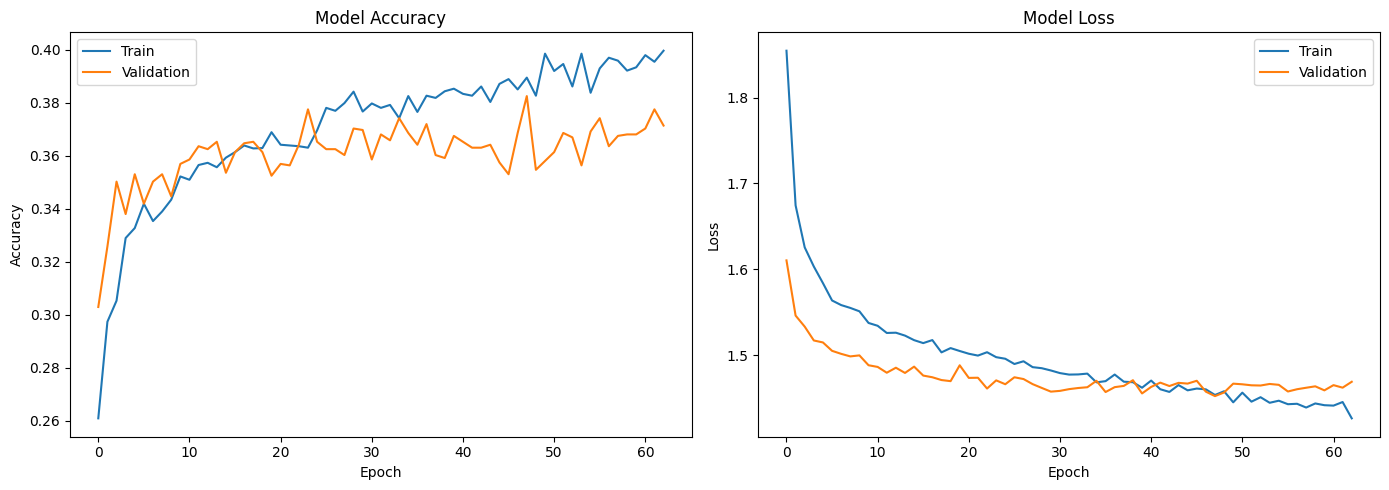

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/mlp_training_history.png")
plt.show()

In [6]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification report
class_names = ['Not-exposed', 'Concerned', 'At Risk', 
                'Vulnerable', 'Severely Vulnerable', 'Highly Vulnerable']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Test Accuracy: 0.3786
Test Loss:     1.4719
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step

Classification Report:
                     precision    recall  f1-score   support

        Not-exposed       0.64      0.70      0.67       376
          Concerned       0.33      0.31      0.32       379
            At Risk       0.38      0.65      0.48       363
         Vulnerable       0.28      0.18      0.22       381
Severely Vulnerable       0.28      0.29      0.29       374
  Highly Vulnerable       0.25      0.15      0.18       372

           accuracy                           0.38      2245
          macro avg       0.36      0.38      0.36      2245
       weighted avg       0.36      0.38      0.36      2245



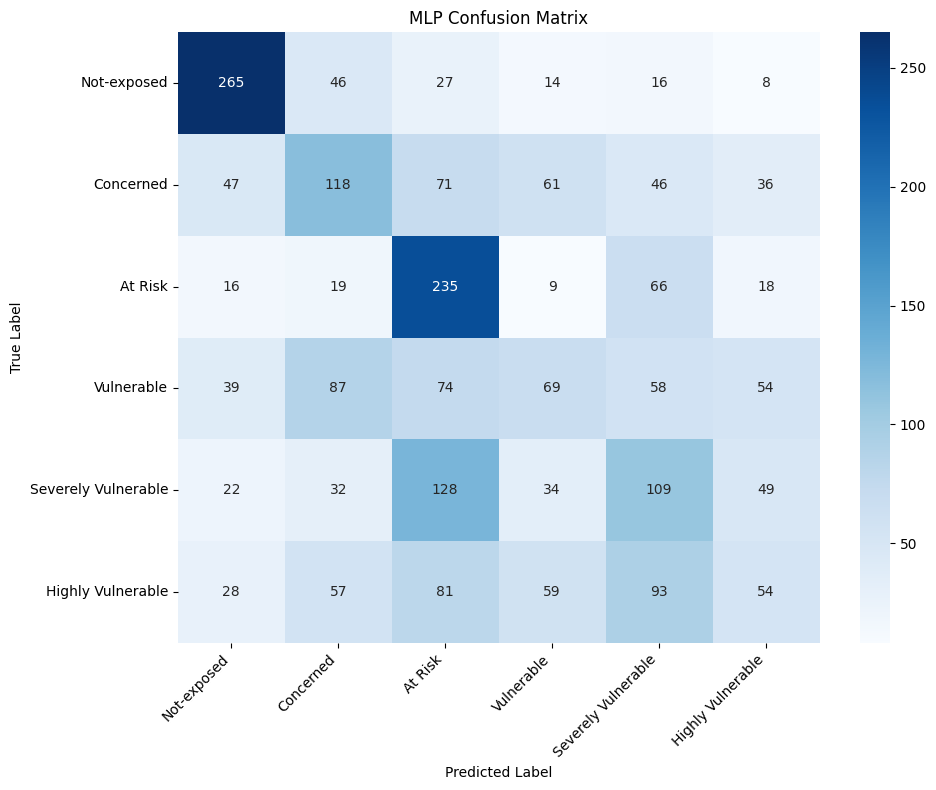

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('MLP Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../outputs/figures/mlp_confusion_matrix.png")
plt.show()